In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

os.chdir('/content/drive/MyDrive/Project/BrainRegionId/Project43/Code')
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
# from ibllib.atlas import AllenAtlas
# from brainbox.io.spikeglx import Streamer
# from neurodsp.voltage import destripe
# from datetime import datetime
# from pprint import pprint

# ba = AllenAtlas()
# br = ba.regions
# ba.compute_regions_volume()


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [4]:
from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:00<00:00, 111.20it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:00<00:00, 31.46it/s]


In [ ]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [ ]:
br

BrainRegions(id=array([         0,        997,          8, ...,        -65,       -624,
       -304325711]), name=array(['void', 'root', 'Basic cell groups and regions', ...,
       'parafloccular sulcus (left)', 'Interpeduncular fossa (left)',
       'retina (left)'], dtype=object), acronym=array(['void', 'root', 'grey', ..., 'pfs', 'IPF', 'retina'], dtype=object), rgb=array([[  0,   0,   0],
       [255, 255, 255],
       [191, 218, 227],
       ...,
       [170, 170, 170],
       [170, 170, 170],
       [127,  46, 126]], dtype=uint8), level=array([0, 0, 1, ..., 3, 2, 1], dtype=uint16), parent=array([   nan,    nan,   997., ..., -1040., -1024.,  -997.]), order=array([   0,    0,    1, ..., 1324, 1325, 1326], dtype=uint16))

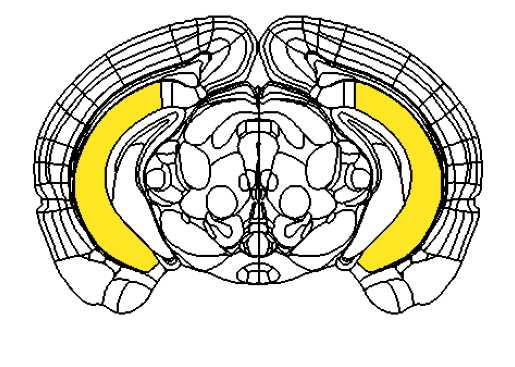

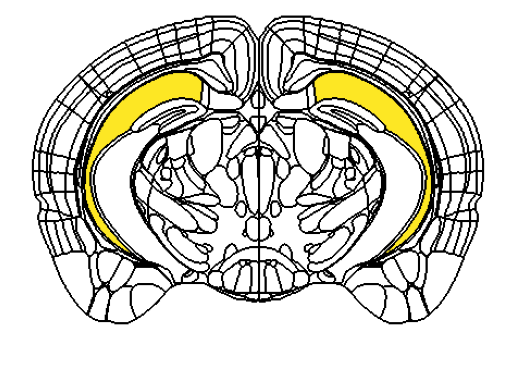

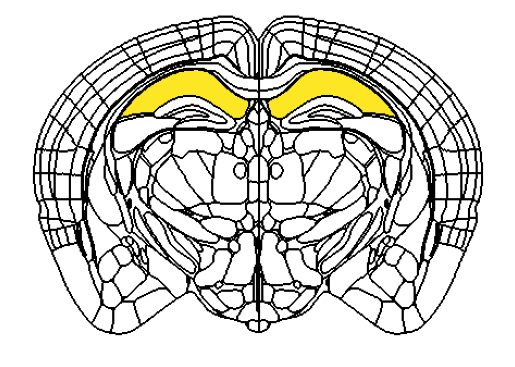

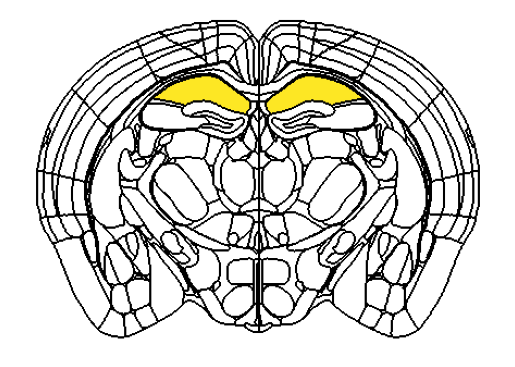

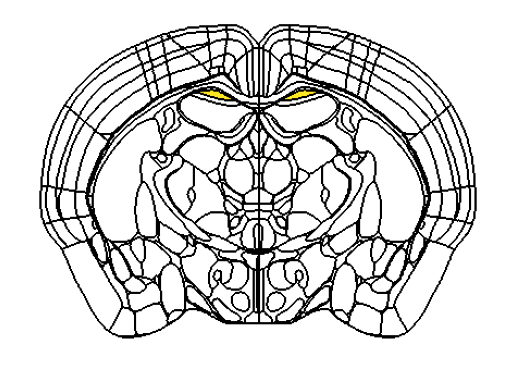

In [ ]:
for indice in range(-3000, -500, 500):
    fig, ax = plot_scalar_on_slice(np.array(['retina', 'CA1']), np.array([0, 0.1]), coord=indice, slice='coronal', mapping='Allen', hemisphere='all',
                                background='boundary', brain_atlas=ba)
    plt.axis('off')

In [ ]:
# 1. Load in trials data
from one.api import ONE
import numpy as np

one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True)
eid = '4720c98a-a305-4fba-affb-bbfa00a724a4'
trials = one.load_object(eid, 'trials')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_014/2020-07-14/001/alf/_ibl_trials.table.pqt: 100%|██████████| 50.4k/50.4k [00:00<00:00, 717kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_014/2020-07-14/001/alf/_ibl_trials.stimOff_times.npy: 100%|██████████| 4.99k/4.99k [00:00<00:00, 118kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_014/2020-07-14/001/alf/_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 4.99k/4.99k [00:00<00:00, 52.6kB/s]


In [ ]:
# 2. Explore the trials object

# Find the keys in our object
keys = trials.keys()

# Convert the trials dict to a pandas dataframe
trials_df = trials.to_df()

# Display the trials table
from IPython.display import display # import module to display dataframe nicely
display(trials_df)

,stimOff_times,goCueTrigger_times,choice,contrastLeft,stimOn_times,response_times,goCue_times,firstMovement_times,probabilityLeft,contrastRight,feedbackType,rewardVolume,feedback_times,intervals_0,intervals_1
0,15.867546,14.145882,-1.0,NaN,14.145685,14.800484,14.146585,14.479997,0.5,1.000,1.0,1.5,14.800586,10.969770,16.367592
1,19.617038,18.296189,1.0,0.2500,18.296037,18.552188,18.296837,18.437997,0.5,NaN,1.0,1.5,18.552278,16.748692,20.117087
2,22.462120,20.979787,-1.0,NaN,20.979602,21.396189,20.980468,21.110997,0.5,0.250,1.0,1.5,21.396293,20.487884,22.962199
3,25.212778,23.834504,-1.0,NaN,23.834316,24.152707,23.835416,24.047997,0.5,0.125,1.0,1.5,24.152818,23.336199,25.712823
4,28.034496,26.650927,-1.0,NaN,26.650735,26.963229,26.651735,26.735997,0.5,0.250,1.0,1.5,26.963303,26.085824,28.534539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,2883.413596,2881.596802,-1.0,NaN,2881.596645,2882.352307,2881.597778,2882.013997,0.2,0.000,1.0,1.5,2882.352403,2881.060798,2883.913720
604,2888.246880,2885.685226,-1.0,0.0625,2885.685069,2886.185928,2885.686069,2885.973997,0.2,NaN,-1.0,0.0,2886.186719,2884.817523,2888.746939
605,2891.918113,2890.201343,-1.0,NaN,2890.201184,2890.846547,2890.201984,2890.420997,0.2,0.250,1.0,1.5,2890.846653,2889.643640,2892.418160
606,2950.578646,2894.046465,1.0,0.1250,2894.046333,2949.519476,2894.047266,2894.367997,0.2,NaN,1.0,1.5,2949.519585,2893.415063,2951.078685


In [ ]:
np.argwhere(np.array(trials_df['stimOn_times'][1:]) - np.array(trials_df['stimOff_times'][:-1]) < 0.7)

array([[400]])

In [ ]:
np.array(trials_df['stimOn_times'][400]) - np.array(trials_df['stimOff_times'][401])

np.float64(-65.64873447006562)

In [ ]:
trials_df[400:410]

,stimOff_times,goCueTrigger_times,choice,contrastLeft,stimOn_times,response_times,goCue_times,firstMovement_times,probabilityLeft,contrastRight,feedbackType,rewardVolume,feedback_times,intervals_0,intervals_1
400,1552.591592,1489.742836,0.0,NaN,1489.742644,1549.744057,1489.743644,1513.011997,0.2,0.1250,-1.0,0.0,1549.744977,1489.178734,1552.244068
401,1555.391379,1553.758474,-1.0,NaN,1553.219729,1554.313478,1553.759242,1553.958997,0.2,0.1250,1.0,1.5,1554.313586,1553.149470,1555.891492
402,1558.669684,1557.286395,-1.0,NaN,1557.286256,1557.586395,1557.287189,1557.450997,0.2,0.2500,1.0,1.5,1557.586492,1556.573094,1559.169800
403,1562.969821,1560.574599,1.0,NaN,1560.574494,1560.895299,1560.575494,1560.741997,0.2,0.0625,-1.0,0.0,1560.896128,1559.853999,1563.469902
404,1566.124572,1564.757704,-1.0,NaN,1564.757542,1565.043406,1564.758409,1564.895997,0.2,0.0000,1.0,1.5,1565.043513,1564.170001,1566.624618
405,1569.319719,1567.819922,-1.0,NaN,1567.819769,1568.234224,1567.820702,1568.022997,0.2,0.0000,1.0,1.5,1568.234328,1567.304521,1569.819732
406,1578.586292,1571.024634,-1.0,0.0000,1571.024515,1576.516157,1571.025348,1571.255997,0.8,NaN,-1.0,0.0,1576.517266,1570.519232,1579.086370
407,1582.274423,1580.874580,1.0,0.0625,1580.874397,1581.188983,1580.875497,1580.981997,0.8,NaN,1.0,1.5,1581.189099,1579.806970,1582.774499
408,1585.624455,1584.219603,-1.0,NaN,1584.219429,1584.549403,1584.220429,1584.419997,0.8,0.2500,1.0,1.5,1584.549496,1583.471204,1586.124504
409,1588.836134,1587.319404,-1.0,NaN,1587.319286,1587.766206,1587.320052,1587.488997,0.8,0.1250,1.0,1.5,1587.766307,1586.821302,1589.336214


In [ ]:
len(trials_df)

608

In [ ]:
trials_df['stimOn_times'][0]

np.float64(14.145685290014146)

In [5]:
def acronym_exp_pid_gen(acronym_dict):

    acronym_exp_dict = {}
    for acronym in acronym_dict:

        args = {}
        args['loc'] = acronym
        print(acronym,'>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>')
        # generate subject list of the acronym
        subject = list(set([acronym_dict[args['loc']][insert_ind]['exp_info']['subject']
                            for insert_ind in range(0, len(acronym_dict[args['loc']]))]))

        exp_num = []
        for subject0 in subject:
            exp_num.append(len(natsorted(list(set([acronym_dict[args['loc']][ind]['exp_info']['date']
                                        for ind in range(0, len(acronym_dict[args['loc']]))
                                            if acronym_dict[args['loc']][ind]['exp_info']['subject'] == subject0])))))

        subject_ind = np.argsort(exp_num).flatten()[::-1]
        subject = np.array(subject)
        subject_list = subject[subject_ind]

        print('subject num: ', len(subject_list))
        # generate date list of subjects
        subject_dat = {}
        for subject0 in subject_list:
            exp_list = natsorted(list(set([acronym_dict[args['loc']][ind]['exp_info']['date']
                                        for ind in range(0, len(acronym_dict[args['loc']]))
                                            if acronym_dict[args['loc']][ind]['exp_info']['subject'] == subject0])))
            subject_dat[subject0] = exp_list
            print(subject0, ': ', len(exp_list))

        acronym_exp_dict[acronym] = subject_dat

    return acronym_exp_dict

In [9]:
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37'

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)


Allen_info = np.load(file_dir + '/Data/dat/acronym_Allen_info.npy', allow_pickle=True).item()
Beryl_info = np.load(file_dir + '/Data/dat/acronym_Beryl_info.npy', allow_pickle=True).item()
################################################################################
acronym_Allen_Beryl_dict = {}
acronym_Allen_Beryl_list = []
for acronym in Allen_info:
    acronym_Allen_Beryl_dict[acronym] = Allen_info[acronym]
for acronym in Beryl_info:
    acronym_Allen_Beryl_dict[acronym] = Beryl_info[acronym]
for acronym in acronym_Allen_Beryl_dict:
    acronym_Allen_Beryl_list.append(acronym)
    print(acronym)

acronym_sub_exp_dict = acronym_exp_pid_gen(acronym_Allen_Beryl_dict)

Streaming output truncated to the last 5000 lines.
CSHL049 :  1
CSHL060 :  1
KS052 :  1
SWC_061 :  1
ibl_witten_19 :  1
SWC_038 :  1
MOs2/3 >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
subject num:  19
KS023 :  3
KS091 :  2
SWC_061 :  2
SWC_038 :  2
CSHL058 :  2
KS052 :  1
SWC_043 :  1
KS094 :  1
CSHL060 :  1
NYU-30 :  1
UCLA037 :  1
ZM_1897 :  1
CSH_ZAD_024 :  1
ibl_witten_19 :  1
ZM_2245 :  1
CSHL049 :  1
ZM_2241 :  1
KS043 :  1
UCLA034 :  1
MOs5 >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
subject num:  28
KS023 :  4
SWC_061 :  3
ibl_witten_19 :  3
KS091 :  2
SWC_038 :  2
CSHL060 :  2
KS052 :  1
NYU-48 :  1
ZFM-02370 :  1
NYU-30 :  1
SWC_043 :  1
ZFM-01936 :  1
ZM_2240 :  1
CSHL058 :  1
ZM_1897 :  1
UCLA033 :  1
CSH_ZAD_024 :  1
NR_0027 :  1
DY_011 :  1
ZFM-01937 :  1
KS046 :  1
ZM_2245 :  1
CSHL049 :  1
ZM_2241 :  1
KS043 :  1
UCLA034 :  1
ZFM-01576 :  1
UCLA035 :  1
MOs6a >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
subject num:  26
SWC_043 :  2
SW

In [18]:
Allen_info['FRP2/3'][0]['exp_info']

{'subject': 'KS094',
 'date': '2022-06-16T11:49:20.330000',
 'number': 1,
 'probe': 'probe01',
 'task_protocol': '_iblrig_tasks_ephysChoiceWorld6.5.3'}

In [19]:
subject_list = []
for acronym in Allen_info:
    for ii in range(0, len(Allen_info[acronym])):
        subject_list.append(Allen_info[acronym][ii]['exp_info']['subject'])

for acronym in Beryl_info:
    for ii in range(0, len(Beryl_info[acronym])):
        subject_list.append(Beryl_info[acronym][ii]['exp_info']['subject'])


In [21]:
np.unique(np.array(subject_list))

array(['CSHL045', 'CSHL047', 'CSHL049', 'CSHL051', 'CSHL052', 'CSHL053',
       'CSHL054', 'CSHL055', 'CSHL058', 'CSHL059', 'CSHL060',
       'CSH_ZAD_001', 'CSH_ZAD_011', 'CSH_ZAD_019', 'CSH_ZAD_022',
       'CSH_ZAD_024', 'CSH_ZAD_025', 'CSH_ZAD_026', 'CSH_ZAD_029',
       'DY_008', 'DY_009', 'DY_010', 'DY_011', 'DY_013', 'DY_014',
       'DY_016', 'DY_018', 'DY_020', 'KS014', 'KS016', 'KS020', 'KS022',
       'KS023', 'KS042', 'KS043', 'KS044', 'KS045', 'KS046', 'KS051',
       'KS052', 'KS055', 'KS074', 'KS075', 'KS084', 'KS086', 'KS091',
       'KS094', 'KS096', 'NR_0017', 'NR_0019', 'NR_0020', 'NR_0021',
       'NR_0027', 'NYU-11', 'NYU-12', 'NYU-21', 'NYU-25', 'NYU-26',
       'NYU-27', 'NYU-29', 'NYU-30', 'NYU-37', 'NYU-39', 'NYU-40',
       'NYU-45', 'NYU-46', 'NYU-47', 'NYU-48', 'PL015', 'PL016', 'PL017',
       'PL024', 'SWC_014', 'SWC_023', 'SWC_038', 'SWC_039', 'SWC_042',
       'SWC_043', 'SWC_052', 'SWC_053', 'SWC_054', 'SWC_058', 'SWC_060',
       'SWC_061', 'SWC_065', 

In [29]:
lab_list = []
for lab in np.unique(np.array(subject_list)):
    for c_ii, c in enumerate(lab):
        if c in ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']:
            lab_list.append(lab[ : c_ii])
            break

print(np.unique(np.array(lab_list)))
print(len(np.unique(np.array(lab_list))))

['CSHL' 'CSH_ZAD_' 'DY_' 'KS' 'NR_' 'NYU-' 'PL' 'SWC_' 'UCLA' 'ZFM-' 'ZM_'
 'ibl_witten_']
12


['CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSHL',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'CSH_ZAD_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'DY_',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'KS',
 'NR_',
 'NR_',
 'NR_',
 'NR_',
 'NR_',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'NYU-',
 'PL',
 'PL',
 'PL',
 'PL',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'SWC_',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'UCLA',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZFM-',
 'ZM_',
 'ZM_',
 'ZM_',
 'ZM_',
 'ZM_',
 'ZM_',
 

In [22]:
len(np.unique(np.array(subject_list)))

127

In [ ]:
Allen_info.keys()

dict_keys(['FRP1', 'FRP2/3', 'FRP5', 'FRP6a', 'MOp1', 'MOp2/3', 'MOp5', 'MOp6a', 'MOp6b', 'MOs1', 'MOs2/3', 'MOs5', 'MOs6a', 'MOs6b', 'SSp-n1', 'SSp-n2/3', 'SSp-n4', 'SSp-n5', 'SSp-n6a', 'SSp-n6b', 'SSp-bfd1', 'SSp-bfd2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'SSp-bfd6b', 'SSp-ll1', 'SSp-ll2/3', 'SSp-ll4', 'SSp-ll5', 'SSp-ll6a', 'SSp-ll6b', 'SSp-m1', 'SSp-m2/3', 'SSp-m4', 'SSp-m5', 'SSp-m6a', 'SSp-m6b', 'SSp-ul1', 'SSp-ul2/3', 'SSp-ul4', 'SSp-ul5', 'SSp-ul6a', 'SSp-ul6b', 'SSp-tr1', 'SSp-tr2/3', 'SSp-tr4', 'SSp-tr5', 'SSp-tr6a', 'SSp-tr6b', 'SSp-un1', 'SSp-un2/3', 'SSp-un4', 'SSp-un5', 'SSp-un6a', 'SSp-un6b', 'SSs2/3', 'SSs4', 'SSs5', 'SSs6a', 'SSs6b', 'GU5', 'GU6a', 'VISC5', 'VISC6a', 'VISC6b', 'AUDd2/3', 'AUDd4', 'AUDd5', 'AUDd6a', 'AUDd6b', 'AUDp4', 'AUDp5', 'AUDp6a', 'AUDpo2/3', 'AUDpo4', 'AUDpo5', 'AUDpo6a', 'AUDpo6b', 'AUDv5', 'AUDv6a', 'AUDv6b', 'VISal2/3', 'VISal4', 'VISal5', 'VISal6a', 'VISal6b', 'VISam1', 'VISam2/3', 'VISam4', 'VISam5', 'VISam6a', 'VISam6b', 'VISl1', 'VISl2/

In [ ]:
from tqdm import tqdm

In [ ]:
pid_list = []
for acronym in Allen_info:
    pid_list.append(Allen_info[acronym][0]['id'])

for acronym in Beryl_info:
    pid_list.append(Beryl_info[acronym][0]['id'])

pid_list = np.unique(np.array(pid_list))

num_trial = 0
num_dec = 0
for pid in tqdm(pid_list):
    try:
        eid, name = one.pid2eid(pid)
        trials = one.load_object(eid, 'trials')
        # Find the keys in our object
        keys = trials.keys()

        # Convert the trials dict to a pandas dataframe
        trials_df = trials.to_df()
        num_trial += len(trials_df)
        num_dec += len(np.argwhere(np.array(trials_df['stimOn_times'][1:]) - np.array(trials_df['stimOff_times'][:-1]) < 1.0))

    except:
        continue
print(num_trial)
print(num_dec)
print(num_dec / num_trial)

 41%|████      | 73/178 [04:09<06:08,  3.51s/it]/usr/local/lib/python3.11/dist-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2024-02-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)
 58%|█████▊    | 104/178 [05:57<03:06,  2.53s/it]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0020/2022-05-11/001/alf/_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 3.79k/3.79k [00:00<00:00, 52.3kB/s]

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0020/2022-05-11/001/alf/_ibl_trials.table.pqt: 100%|██████████| 40.1k/40.1k [00:00<00:00, 650kB/s]

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0020/2022-05-11/001/alf/_ibl_trials.stimOff_times.npy: 100%|██████████| 3.79k/3.79k [00:00<00:00, 71.9kB/s]
 59%|█████▉    | 105/178 [06:02<03:52,  3.19s/it]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-46/2021-06-22/

113486
59
0.0005198879156900411


In [ ]:
print(f'Total trial number: {num_trial}')
print(f'less than 1s trial number: {num_dec}')
print(f'ratio: {num_dec / num_trial}')
print(f'percent: {num_dec / num_trial * 100} %')


Total trial number: 113486
less than 1s trial number: 59
ratio: 0.0005198879156900411
percent: 0.05198879156900411 %


In [ ]:
pid_list

array(['0228bcfd-632e-49bd-acd4-c334cf9213e9',
       '0259543e-1ca3-48e7-95c9-53f9e4c9bfcc',
       '05ec6af9-6c83-422d-91a3-ba815fa65e92',
       '06c6741e-9f2a-4114-8ca9-0dc5ccc951e6',
       '06cb2ee3-0fb8-4ace-acbe-19c716f3ca40',
       '06d42449-d6ac-4c35-8f85-24ecfbc08bc1',
       '07c79864-6fff-4e72-9fce-1c982e3457f9',
       '082187a0-121f-47d5-962a-a9ad467e7124',
       '0909252c-3ad0-413f-96f5-7eff885b50aa',
       '09b62a15-dd8b-4f47-881f-d3f1e5ea5ff4',
       '0a0184b3-9e1a-4c36-98f4-00ae3beb8f01',
       '0f306cdc-878a-4ea0-9e91-b97736731637',
       '0fcb5f66-4d56-4247-8413-aef51e484e67',
       '100433fa-2c59-4432-8295-aa27657fe3fb',
       '10ef1dcd-093c-4839-8f38-90a25edefb49',
       '176b4fe3-f570-4d9f-9e25-a5d218f75c8b',
       '1878c999-d523-474a-9d4e-8dde53d7324c',
       '18be19f9-6ca5-4fc8-9220-ba43c3e75905',
       '19c5b0d5-a255-47ff-9f8d-639e634a7b61',
       '1ab86a7f-578b-4a46-9c9c-df3be97abcca',
       '1df6ebb3-9d16-4c0f-96cc-e1b1596d2006',
       '1f555

In [ ]:
eid, name = one.pid2eid(pid)
trials = one.load_object(, 'trials')

In [ ]:
one.load_object()